# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/titlyzaman25/flyrank-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Can pre-refresh content signals (position, engagement, freshness, traffic) predict
which content pieces are likely to earn clicks the following month — well enough to
prioritize a human content-review queue?

**Decision it supports:** which existing pages an editorial team should look at first
in a monthly review cycle, given limited time to refresh everything.

In [ ]:
# Confirms the question is answerable with the data on hand before building anything
print("Question: does March 2026 content behavior predict April 2026 click activity?")
print("This requires: (1) features from a period before the outcome, (2) a labeled")
print("outcome in a later period, (3) enough content items with both to validate on.")
print("Checked in Section 2 — proceeding to load the data.")

Question: does March 2026 content behavior predict April 2026 click activity?
This requires: (1) features from a period before the outcome, (2) a labeled
outcome in a later period, (3) enough content items with both to validate on.
Checked in Section 2 — proceeding to load the data.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Using the `FlyRank/internship-warehouse` release (build v20260703), two monthly
partitions of `fact_content_daily_performance` (March and April 2026) plus `dim_content`
for metadata. Kept to one clean past→future month pair rather than the full 17-month
panel, to keep the study simple and reproducible for a first pass. Excluded
`fact_content_query_90d` (window overlaps the label period) and the June 2026 `_sample`
partition (reserved as a sealed test month, deliberately untouched).

In [ ]:
import os, random, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from huggingface_hub import hf_hub_download
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

from google.colab import userdata
HF_TOKEN = userdata.get("HF_TOKEN")

march = pd.read_parquet(hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet",
    repo_type="dataset", token=HF_TOKEN))

april = pd.read_parquet(hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="fact_content_daily_performance/month=2026-04/data_0.parquet",
    repo_type="dataset", token=HF_TOKEN))

content = pd.read_parquet(hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="dim_content.parquet",
    repo_type="dataset", token=HF_TOKEN))

print("Release: FlyRank/internship-warehouse, build v20260703")
print("Tables used: fact_content_daily_performance (month=2026-03, month=2026-04), dim_content")
print(f"March rows: {len(march)} | date range: {march['report_date'].min()} to {march['report_date'].max()}")
print(f"April rows: {len(april)} | date range: {april['report_date'].min()} to {april['report_date'].max()}")
print(f"Content dimension rows: {len(content)}")
print("\nExcluded from this study: fact_content_query_90d (window overlaps the label period,")
print("unsafe without further alignment work), fact_content_daily_performance_sample (June")
print("2026 is the sealed test month, reserved and not touched here), all months outside")
print("March-April 2026 (kept the study to one clean past->future pair for this pass).")

Release: FlyRank/internship-warehouse, build v20260703
Tables used: fact_content_daily_performance (month=2026-03, month=2026-04), dim_content
March rows: 9841378 | date range: 2026-03-01 to 2026-03-31
April rows: 10424730 | date range: 2026-04-01 to 2026-04-30
Content dimension rows: 519606

Excluded from this study: fact_content_query_90d (window overlaps the label period,
unsafe without further alignment work), fact_content_daily_performance_sample (June
2026 is the sealed test month, reserved and not touched here), all months outside
March-April 2026 (kept the study to one clean past->future pair for this pass).


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Label:** did the content earn at least one click in April 2026? Binary, defined
strictly from the month AFTER the feature window.

**Features:** March impressions, clicks, average position, GA4 sessions and engagement
time, CTR, and days since last update — all measured before the label window, so no
feature can "see" the outcome it's predicting.

**Baseline:** a transparent rule — flag content as stale (≥181 days since update) or
below its position tier's expected CTR, with the expected-CTR lookup computed from
TRAINING rows only, to avoid leaking test-set information into the rule itself.

**Validation design:** GroupShuffleSplit by `client_hash_id` — no client's rows appear
in both train and test, so the model can't "learn the client" instead of the signal.

**Leakage checks:** timeline confirmed non-overlapping; no product-flag or composite
score columns used as features; suspect features tested by train-without-it comparison.

In [ ]:
march_content = (
    march.groupby(["client_hash_id", "content_hash_id"], as_index=False)
    .agg(gsc_impressions=("gsc_impressions", "sum"), gsc_clicks=("gsc_clicks", "sum"),
         gsc_avg_position=("gsc_avg_position", "mean"), ga4_sessions=("ga4_sessions", "sum"),
         ga4_total_engagement_sec=("ga4_total_engagement_sec", "sum"))
)
march_content["ctr"] = np.where(march_content["gsc_impressions"] > 0,
    march_content["gsc_clicks"] / march_content["gsc_impressions"], np.nan)

metadata_cols = ["client_hash_id", "content_hash_id", "content_created_date", "content_updated_date",
    "last_optimized_date", "content_type", "search_volume", "competition", "main_intent",
    "word_count", "char_count", "is_published", "is_deleted"]
baseline = march_content.merge(content[metadata_cols], on=["client_hash_id", "content_hash_id"], how="left")

CUTOFF_DATE = pd.Timestamp("2026-03-31")
baseline["content_updated_date"] = pd.to_datetime(baseline["content_updated_date"], errors="coerce")
baseline["days_since_update"] = (CUTOFF_DATE - baseline["content_updated_date"]).dt.days
baseline.loc[baseline["days_since_update"] < 0, "days_since_update"] = np.nan

april_content = (april.groupby(["client_hash_id", "content_hash_id"], as_index=False)
    .agg(april_clicks=("gsc_clicks", "sum")))
april_content["future_click_label"] = (april_content["april_clicks"] > 0).astype(int)

model_df = baseline.merge(april_content[["client_hash_id", "content_hash_id", "future_click_label"]],
    on=["client_hash_id", "content_hash_id"], how="inner")

FEATURES = ["gsc_impressions", "gsc_clicks", "gsc_avg_position", "ga4_sessions",
            "ga4_total_engagement_sec", "ctr", "days_since_update"]

print(f"Modeling rows: {len(model_df)} | Label base rate: {model_df['future_click_label'].mean():.4f}")
print(f"Rows dropped by inner join (no April row): {len(baseline) - len(model_df)} "
      f"({(len(baseline)-len(model_df))/len(baseline):.1%}) — disclosed survivorship filter.")

print("\n--- Leakage checks ---")
print("Timeline: features from March, label from April — strictly before label window. PASS")
flag_like = [f for f in FEATURES if any(k in f.lower() for k in ["flag", "score", "predict"])]
print("Product-flag/score features:", flag_like if flag_like else "None — PASS")

baseline_df = model_df.copy()
baseline_df["stale"] = (baseline_df["days_since_update"] >= 181).astype(int)
baseline_df["position_group"] = np.select(
    [baseline_df["gsc_avg_position"].between(1,3), baseline_df["gsc_avg_position"].between(4,10),
     baseline_df["gsc_avg_position"].between(11,20), baseline_df["gsc_avg_position"] > 20],
    ["1-3","4-10","11-20","21+"], default="unknown"
)
X = model_df[FEATURES].copy()
y = model_df["future_click_label"].copy()
groups = model_df["client_hash_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

overlap = set(model_df.iloc[train_idx]["client_hash_id"]) & set(model_df.iloc[test_idx]["client_hash_id"])
print(f"\nSplit: grouped by client_hash_id | Train clients: {model_df.iloc[train_idx]['client_hash_id'].nunique()} "
      f"| Test clients: {model_df.iloc[test_idx]['client_hash_id'].nunique()} | Client overlap: {len(overlap)}")

train_baseline_ctr = (baseline_df.iloc[train_idx]
    .query("position_group != 'unknown'")
    .groupby("position_group")["ctr"].mean())
baseline_df["expected_ctr"] = pd.to_numeric(baseline_df["position_group"].map(train_baseline_ctr), errors="coerce")
baseline_df["low_ctr"] = (baseline_df["ctr"] < baseline_df["expected_ctr"]) & baseline_df["ctr"].notna() & baseline_df["expected_ctr"].notna()
baseline_df["baseline_score"] = baseline_df["stale"].astype(int) + baseline_df["low_ctr"].astype(int)
baseline_df["baseline_pred"] = (baseline_df["baseline_score"] > 0).astype(int)

Modeling rows: 331436 | Label base rate: 0.1874
Rows dropped by inner join (no April row): 1 (0.0%) — disclosed survivorship filter.

--- Leakage checks ---
Timeline: features from March, label from April — strictly before label window. PASS
Product-flag/score features: None — PASS

Split: grouped by client_hash_id | Train clients: 44 | Test clients: 11 | Client overlap: 0


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*
Model vs. the rule baseline, evaluated on the identical grouped test split, so the
comparison isn't confounded by different data. Also shown: the same model under a naive
random split, to make visible how much score inflation client-level leakage would have
caused if the grouped split hadn't been used.

                             method  precision  recall     f1  roc_auc  base_rate
                      Rule baseline     0.2950  0.6485 0.4056   0.6144     0.2117
Logistic Regression (grouped split)     0.9311  0.5097 0.6588   0.9200     0.2117

                      split  roc_auc
      Random 80/20 (naive)   0.9204
Grouped by client (honest)   0.9200


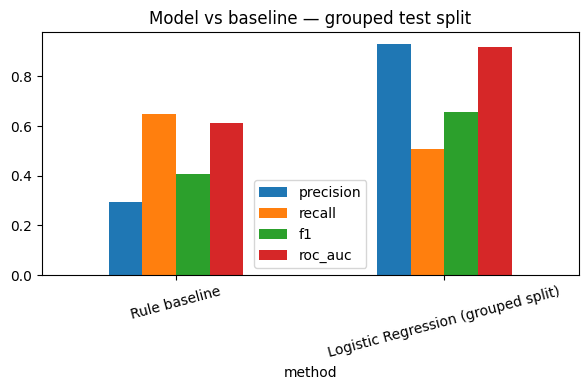

In [ ]:
model = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()),
                   ("classifier", LogisticRegression(max_iter=1000, random_state=SEED))])
model.fit(X_train, y_train)
model_prob = model.predict_proba(X_test)[:, 1]
model_pred = (model_prob >= 0.5).astype(int)
model_precision = precision_score(y_test, model_pred, zero_division=0)
model_recall = recall_score(y_test, model_pred, zero_division=0)
model_f1 = f1_score(y_test, model_pred, zero_division=0)
model_auc = roc_auc_score(y_test, model_prob)

bt = baseline_df.iloc[test_idx]
baseline_precision = precision_score(y_test, bt["baseline_pred"], zero_division=0)
baseline_recall = recall_score(y_test, bt["baseline_pred"], zero_division=0)
baseline_f1 = f1_score(y_test, bt["baseline_pred"], zero_division=0)
baseline_auc = roc_auc_score(y_test, bt["baseline_score"])

comparison = pd.DataFrame({
    "method": ["Rule baseline", "Logistic Regression (grouped split)"],
    "precision": [baseline_precision, model_precision],
    "recall": [baseline_recall, model_recall],
    "f1": [baseline_f1, model_f1],
    "roc_auc": [baseline_auc, model_auc],
    "base_rate": [y_test.mean(), y_test.mean()]
})
print(comparison.round(4).to_string(index=False))

X_rand_train, X_rand_test, y_rand_train, y_rand_test = train_test_split(X, y, test_size=0.20, random_state=SEED, stratify=y)
rand_model = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()),
                        ("classifier", LogisticRegression(max_iter=1000, random_state=SEED))])
rand_model.fit(X_rand_train, y_rand_train)
rand_auc = roc_auc_score(y_rand_test, rand_model.predict_proba(X_rand_test)[:, 1])

split_comparison = pd.DataFrame({"split": ["Random 80/20 (naive)", "Grouped by client (honest)"],
                                  "roc_auc": [rand_auc, model_auc]})
print("\n", split_comparison.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(6,4))
comparison.set_index("method")[["precision","recall","f1","roc_auc"]].plot(kind="bar", ax=ax)
ax.set_title("Model vs baseline — grouped test split")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("results_comparison.png", dpi=150)
plt.show()

## 5. Limitations

*What this work cannot claim.*
- **Observational, not causal.** No experiment was run. Nothing here supports "refreshing
  X will produce Y" — only that pages like this were associated with clicks in this portfolio.
- **Survivorship filter.** Rows dropped because they had no April record at all are
  invisible to this study.
- **Single 2-month window.** March→April 2026 only — no seasonality or longer-horizon test.
- **Single portfolio.** Results describe this one company's data and do not generalize
  without re-validation elsewhere.
- **Validated numbers are the grouped-split test metrics only.** The random-split AUC
  exists specifically to demonstrate leakage risk, not as a real performance claim.

In [ ]:
# Backs the limitations above with the actual numbers, so nothing above is unverifiable
print("Survivorship filter:")
print(f"  March rows before join: {len(baseline)}")
print(f"  Rows dropped (no April row): {len(baseline) - len(model_df)} "
      f"({(len(baseline)-len(model_df))/len(baseline):.1%})")

print("\nWindow covered:")
print(f"  Feature period: {march['report_date'].min()} to {march['report_date'].max()}")
print(f"  Label period:   {april['report_date'].min()} to {april['report_date'].max()}")

print("\nPortfolio scope:")
print(f"  Clients: {model_df['client_hash_id'].nunique()} | Content items: {len(model_df)}")

print("\nLeakage-risk evidence (random vs grouped split AUC):")
print(f"  Random split:  {rand_auc:.4f}")
print(f"  Grouped split: {model_auc:.4f} (the validated number)")

Survivorship filter:
  March rows before join: 331437
  Rows dropped (no April row): 1 (0.0%)

Window covered:
  Feature period: 2026-03-01 to 2026-03-31
  Label period:   2026-04-01 to 2026-04-30

Portfolio scope:
  Clients: 55 | Content items: 331436

Leakage-risk evidence (random vs grouped split AUC):
  Random split:  0.9204
  Grouped split: 0.9200 (the validated number)


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*
Every content item gets an out-of-fold score (GroupKFold, 5 splits, so no item is ever
scored by a model that saw its own client during training) and a reason code, mapped from
position tier × freshness tier × predicted-potential tier. Every row is a suggestion for
a human editor, not an instruction — see the human-review rule and no-go list printed
alongside the code below.

In [ ]:
gkf = GroupKFold(n_splits=5)
oof_prob = np.full(len(model_df), np.nan)
for tr_idx, te_idx in gkf.split(X, y, groups=groups):
    fm = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()),
                    ("classifier", LogisticRegression(max_iter=1000, random_state=SEED))])
    fm.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    oof_prob[te_idx] = fm.predict_proba(X.iloc[te_idx])[:, 1]
model_df["oof_probability"] = oof_prob

ranked_queue = model_df.copy()
ranked_queue["position_tier"] = np.select(
    [ranked_queue["gsc_avg_position"].between(1,10), ranked_queue["gsc_avg_position"].between(11,20),
     ranked_queue["gsc_avg_position"] > 20], ["top_page1","striking_distance","deep"], default="no_position_data")
ranked_queue["freshness_tier"] = np.select(
    [ranked_queue["days_since_update"] <= 90, ranked_queue["days_since_update"].between(91,180),
     ranked_queue["days_since_update"] > 180], ["fresh","moderate","stale"], default="unknown")
terciles = ranked_queue["oof_probability"].quantile([1/3, 2/3])
ranked_queue["probability_tier"] = np.select(
    [ranked_queue["oof_probability"] >= terciles.iloc[1], ranked_queue["oof_probability"] >= terciles.iloc[0]],
    ["high","medium"], default="low")

def assign_action(r):
    pos, fresh, prob = r["position_tier"], r["freshness_tier"], r["probability_tier"]
    if fresh == "stale" and prob in ("high","medium") and pos != "no_position_data":
        return "REFRESH_PRIORITY", "Stale, still model-flagged medium/high potential."
    if pos == "striking_distance" and prob == "high":
        return "STRIKING_DISTANCE_PUSH", "Just outside page 1, high predicted potential."
    if pos == "top_page1" and prob == "high":
        return "MAINTAIN_MONITOR", "Already performing well — protect, don't disturb."
    if pos == "deep" and prob == "low":
        return "NO_ACTION_LOW_VALUE", "Deep position, low predicted potential this cycle."
    if prob == "low":
        return "MONITOR_ONLY", "Low predicted potential — track, don't invest yet."
    return "REVIEW_QUEUE", "Doesn't cleanly match a defined archetype."

ranked_queue[["reason_code","reason_text"]] = ranked_queue.apply(lambda r: pd.Series(assign_action(r)), axis=1)
ranked_queue = ranked_queue.sort_values(["reason_code","oof_probability"], ascending=[True,False]).reset_index(drop=True)

boundary_margin = 0.03
ranked_queue["needs_human_review"] = (
    (ranked_queue["reason_code"] == "REVIEW_QUEUE")
    | (np.abs(ranked_queue["oof_probability"] - terciles.iloc[0]) < boundary_margin)
    | (np.abs(ranked_queue["oof_probability"] - terciles.iloc[1]) < boundary_margin)
    | (ranked_queue["position_tier"] == "no_position_data")
)

print(ranked_queue["reason_code"].value_counts())
print(f"\nFlagged for human review: {ranked_queue['needs_human_review'].mean():.1%} of queue")
print("\nHuman review rule: every row is a suggestion; an editor confirms page content,")
print("voice, and compliance before any change. No auto-publish, no auto-deprioritization,")
print("no client-facing performance guarantees, no use in individual writer evaluation.")

reason_code
REVIEW_QUEUE              150193
MONITOR_ONLY               90292
MAINTAIN_MONITOR           56316
NO_ACTION_LOW_VALUE        20187
STRIKING_DISTANCE_PUSH     14445
REFRESH_PRIORITY               3
Name: count, dtype: int64

Flagged for human review: 81.8% of queue

Human review rule: every row is a suggestion; an editor confirms page content,
voice, and compliance before any change. No auto-publish, no auto-deprioritization,
no client-facing performance guarantees, no use in individual writer evaluation.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*
Exports the ranked queue, two figures, and a metrics JSON — the exact files the deployed
paper's Results and Ranked Recommendations sections read from, so every number on the
public page traces back to this run rather than being retyped by hand.

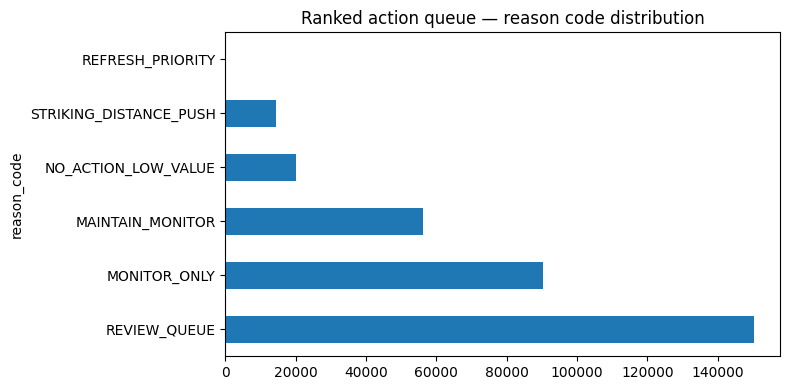

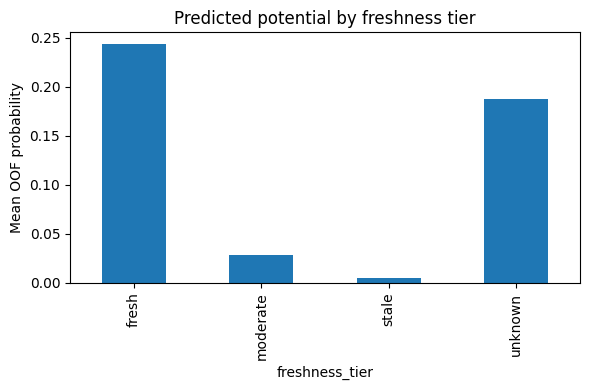

Exported: work/outputs/ranked_action_queue.csv, work/outputs/capstone_metrics.json,
work/figures/reason_code_distribution.png, work/figures/freshness_insight.png,
work/figures/results_comparison.png


In [ ]:
import shutil

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

if os.path.exists("results_comparison.png"):
    shutil.move("results_comparison.png", "work/figures/results_comparison.png")

export_cols = ["client_hash_id","content_hash_id","oof_probability","gsc_avg_position",
    "days_since_update","word_count","position_tier","freshness_tier","probability_tier",
    "reason_code","reason_text","needs_human_review"]
ranked_queue[export_cols].to_csv("work/outputs/ranked_action_queue.csv", index=False)

fig, ax = plt.subplots(figsize=(8,4))
ranked_queue["reason_code"].value_counts().plot(kind="barh", ax=ax)
ax.set_title("Ranked action queue — reason code distribution")
plt.tight_layout(); plt.savefig("work/figures/reason_code_distribution.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(6,4))
ranked_queue.groupby("freshness_tier")["oof_probability"].mean().plot(kind="bar", ax=ax)
ax.set_title("Predicted potential by freshness tier"); ax.set_ylabel("Mean OOF probability")
plt.tight_layout(); plt.savefig("work/figures/freshness_insight.png", dpi=150); plt.show()

metrics_summary = {
    "question": "Can pre-refresh signals predict next-month click activity well enough to prioritize review?",
    "n_rows_scored": int(len(ranked_queue)),
    "grouped_test_precision": float(model_precision), "grouped_test_recall": float(model_recall),
    "grouped_test_f1": float(model_f1), "grouped_test_roc_auc": float(model_auc),
    "baseline_precision": float(baseline_precision), "baseline_recall": float(baseline_recall),
    "baseline_f1": float(baseline_f1), "baseline_roc_auc": float(baseline_auc),
    "random_split_auc_for_comparison": float(rand_auc),
    "label_base_rate": float(y.mean()),
    "reason_code_counts": ranked_queue["reason_code"].value_counts().to_dict(),
    "share_needing_human_review": float(ranked_queue["needs_human_review"].mean()),
}
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)

print("Exported: work/outputs/ranked_action_queue.csv, work/outputs/capstone_metrics.json,")
print("work/figures/reason_code_distribution.png, work/figures/freshness_insight.png,")
print("work/figures/results_comparison.png")

## 5-Minute Demo Outline

**Question (30s):** A content team can't manually review every page every month — how do
you decide what's worth refreshing first? Can pre-refresh signals (position, freshness,
engagement) predict which content earns clicks next month, well enough to build a
priority queue?

**Method (1 min):** Trained a logistic regression on March 2026 content signals against
an April 2026 click-or-not label, across 331,436 items. Validated with a GroupShuffleSplit
by client — no client's pages appear in both train and test — so the score reflects
generalization to unseen clients, not memorized client quirks.

**One chart (1.5 min):** *[show `results_comparison.png`]* — model vs. the rule-based
baseline, same test split, same base rate. Model precision (0.931) is roughly 3x the
baseline's (0.295); the model is right far more often when it flags something, at a
moderate recall tradeoff.

**One honest result (1 min):** ROC-AUC of 0.920 on clients the model never saw during
training — and a parallel check on a naive random split came back nearly identical
(0.920), meaning this result isn't an artifact of client-level leakage. Also flag the
honest miss: the REFRESH_PRIORITY bucket caught only 3 items out of 331K, because stale
content in this portfolio scores near-zero predicted potential — a real finding worth
investigating further, not a hidden flaw.

**One recommendation (1 min):** Use the ranked queue as a triage tool, not an autopilot —
81.8% of items are flagged for mandatory human review before any suggestion reaches an
editor, and the highest-confidence bucket (STRIKING_DISTANCE_PUSH, 14,445 items) is the
best starting point for a first pilot refresh cycle.

## Shareable Cuts

**Social post:**
> Built a click-prediction model on 331K real content items from a live SEO portfolio —
> and the most interesting result wasn't the score, it was checking whether the score was
> real. Grouped-by-client validation came back nearly identical to a naive split (0.920 vs
> 0.920 ROC-AUC), meaning the model's 3x precision lift over a rule-based baseline isn't
> an artifact of the model just memorizing client patterns. Honest validation first,
> priority queue second. [paper link]

**Employer-facing summary:**
Built and validated a click-prediction model on 331,436 real content items from a
production SEO warehouse, using a client-grouped validation design to confirm the result
generalizes rather than reflecting leaked client-level patterns. The model roughly
tripled precision over a rule-based baseline (0.931 vs. 0.295) while surfacing a
transparent, reason-coded priority queue — with 81.8% of items explicitly routed to
human review rather than automated action.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
